In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
file_path="/content/drive/MyDrive/StudentsPerformance.csv"

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv(file_path)
print("Dataset loaded successfully!")
print(df.head())

Dataset loaded successfully!
   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  math score  reading score  writing score  
0                    none          72             72             74  
1               completed          69             90             88  
2                    none          90             95             93  
3                    none          47             57             44  
4                    none          76             78             75  


In [5]:
print("Shape of Dataset:", df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nDataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

Shape of Dataset: (1000, 8)

Column Names:
Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB

Missing Values:
gende

In [6]:
categorical_features = df.select_dtypes(include='object').columns
print("Categorical Features:")
print(list(categorical_features))

Categorical Features:
['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']


In [7]:
for col in categorical_features:
    print("\n", col)
    print(df[col].value_counts())


 gender
gender
female    518
male      482
Name: count, dtype: int64

 race/ethnicity
race/ethnicity
group C    319
group D    262
group B    190
group E    140
group A     89
Name: count, dtype: int64

 parental level of education
parental level of education
some college          226
associate's degree    222
high school           196
some high school      179
bachelor's degree     118
master's degree        59
Name: count, dtype: int64

 lunch
lunch
standard        645
free/reduced    355
Name: count, dtype: int64

 test preparation course
test preparation course
none         642
completed    358
Name: count, dtype: int64


In [11]:
df['Total Marks'] = (
    df['math score'] +
    df['reading score'] +
    df['writing score']
)

print(df[['math score', 'reading score', 'writing score', 'Total Marks']].head())

   math score  reading score  writing score  Total Marks
0          72             72             74          218
1          69             90             88          247
2          90             95             93          278
3          47             57             44          148
4          76             78             75          229


In [8]:
subject_columns = [
    'math score',
    'reading score',
    'writing score'
]

statistics = df[subject_columns].describe().T

print(statistics)

                count    mean        std   min    25%   50%   75%    max
math score     1000.0  66.089  15.163080   0.0  57.00  66.0  77.0  100.0
reading score  1000.0  69.169  14.600192  17.0  59.00  70.0  79.0  100.0
writing score  1000.0  68.054  15.195657  10.0  57.75  69.0  79.0  100.0


In [12]:
df['Percentage'] = (df['Total Marks'] / 300) * 100

print(df[['Total Marks', 'Percentage']].head())

   Total Marks  Percentage
0          218   72.666667
1          247   82.333333
2          278   92.666667
3          148   49.333333
4          229   76.333333


In [13]:
for col in subject_columns:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower_limit) |
        (df[col] > upper_limit)
    ]

    print("\nSubject:", col)
    print("Q1:", Q1)
    print("Q3:", Q3)
    print("IQR:", IQR)
    print("Lower Limit:", lower_limit)
    print("Upper Limit:", upper_limit)
    print("Number of Outliers:", len(outliers))


Subject: math score
Q1: 57.0
Q3: 77.0
IQR: 20.0
Lower Limit: 27.0
Upper Limit: 107.0
Number of Outliers: 8

Subject: reading score
Q1: 59.0
Q3: 79.0
IQR: 20.0
Lower Limit: 29.0
Upper Limit: 109.0
Number of Outliers: 6

Subject: writing score
Q1: 57.75
Q3: 79.0
IQR: 21.25
Lower Limit: 25.875
Upper Limit: 110.875
Number of Outliers: 5


In [14]:
outlier_rows = pd.DataFrame()

for col in subject_columns:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    temp = df[
        (df[col] < lower_limit) |
        (df[col] > upper_limit)
    ].copy()

    temp['Outlier Subject'] = col

    outlier_rows = pd.concat([outlier_rows, temp])

print(outlier_rows)

     gender race/ethnicity parental level of education         lunch  \
17   female        group B            some high school  free/reduced   
59   female        group C            some high school  free/reduced   
145  female        group C                some college  free/reduced   
338  female        group B            some high school  free/reduced   
466  female        group D          associate's degree  free/reduced   
787  female        group B                some college      standard   
842  female        group B                 high school  free/reduced   
980  female        group B                 high school  free/reduced   
59   female        group C            some high school  free/reduced   
76     male        group E            some high school      standard   
211    male        group C                some college  free/reduced   
327    male        group A                some college  free/reduced   
596    male        group B                 high school  free/red

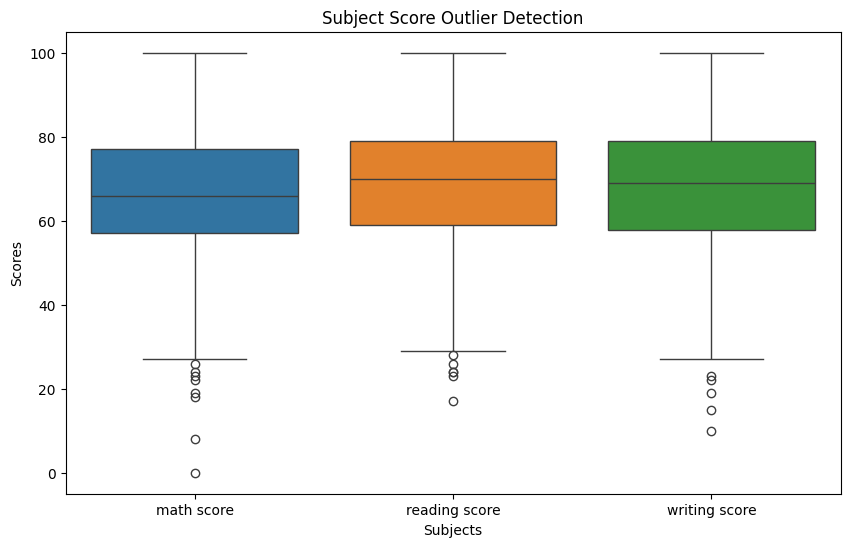

In [15]:
plt.figure(figsize=(10, 6))

sns.boxplot(data=df[subject_columns])

plt.title("Subject Score Outlier Detection")
plt.xlabel("Subjects")
plt.ylabel("Scores")

plt.show()

In [16]:
print(df.head())
print(df.shape)

   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  math score  reading score  writing score  \
0                    none          72             72             74   
1               completed          69             90             88   
2                    none          90             95             93   
3                    none          47             57             44   
4                    none          76             78             75   

   Total Marks  Percentage  
0          218   72.666667  
1          247   82.333333  
2          278   92.666667  
3          148   49.333333  
4      

In [17]:
print(df.isnull().sum())

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
Total Marks                    0
Percentage                     0
dtype: int64


In [18]:
df.to_csv("Student_Performance_Cleaned.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [10]:
print("STATISTICAL MEASURES")

for subject in subjects:
    print("\nSubject:", subject)
    print("Mean:", df[subject].mean())
    print("Median:", df[subject].median())
    print("Standard Deviation:", df[subject].std())
    print("Q1:", df[subject].quantile(0.25))
    print("Q2:", df[subject].quantile(0.50))
    print("Q3:", df[subject].quantile(0.75))

STATISTICAL MEASURES

Subject: math score
Mean: 66.089
Median: 66.0
Standard Deviation: 15.163080096009468
Q1: 57.0
Q2: 66.0
Q3: 77.0

Subject: reading score
Mean: 69.169
Median: 70.0
Standard Deviation: 14.60019193725222
Q1: 59.0
Q2: 70.0
Q3: 79.0

Subject: writing score
Mean: 68.054
Median: 69.0
Standard Deviation: 15.195657010869642
Q1: 57.75
Q2: 69.0
Q3: 79.0


In [19]:
subject_means = df[subject_columns].mean()

print(subject_means)

math score       66.089
reading score    69.169
writing score    68.054
dtype: float64


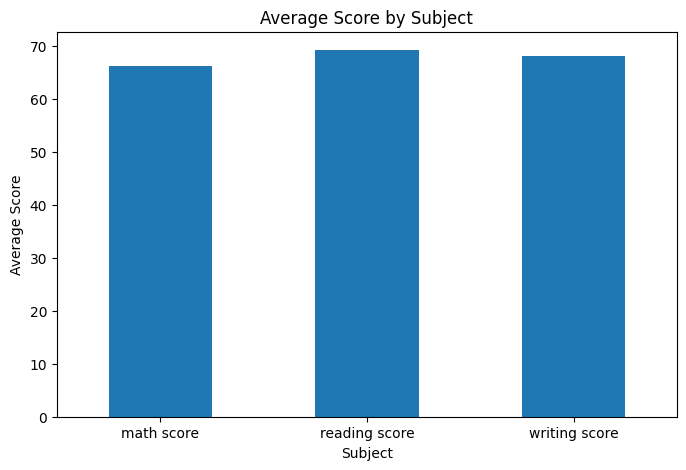

In [20]:
subject_means.plot(kind='bar', figsize=(8,5))

plt.title("Average Score by Subject")
plt.xlabel("Subject")
plt.ylabel("Average Score")
plt.xticks(rotation=0)

plt.show()

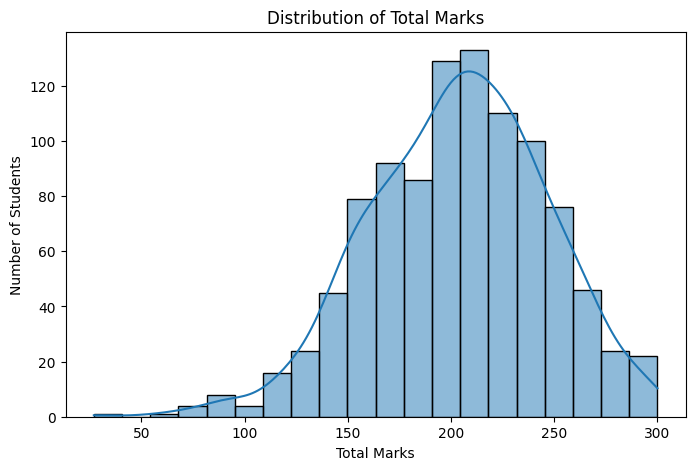

In [21]:
plt.figure(figsize=(8,5))

sns.histplot(df['Total Marks'], bins=20, kde=True)

plt.title("Distribution of Total Marks")
plt.xlabel("Total Marks")
plt.ylabel("Number of Students")

plt.show()

In [23]:
correlation = df[subject_columns].corr()

print(correlation)

               math score  reading score  writing score
math score       1.000000       0.817580       0.802642
reading score    0.817580       1.000000       0.954598
writing score    0.802642       0.954598       1.000000


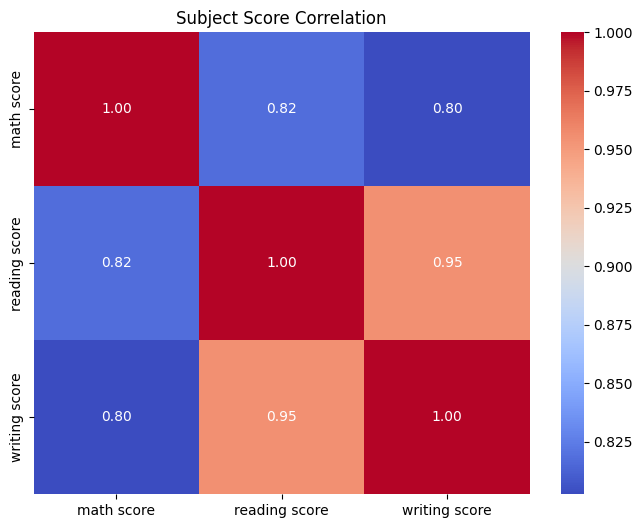

In [24]:
plt.figure(figsize=(8,6))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Subject Score Correlation")

plt.show()

In [25]:
def performance_category(percentage):
    if percentage >= 75:
        return 'Excellent'
    elif percentage >= 60:
        return 'Good'
    elif percentage >= 40:
        return 'Average'
    else:
        return 'Poor'

df['Performance Category'] = df['Percentage'].apply(performance_category)

print(df[['Total Marks', 'Percentage', 'Performance Category']].head())

   Total Marks  Percentage Performance Category
0          218   72.666667                 Good
1          247   82.333333            Excellent
2          278   92.666667            Excellent
3          148   49.333333              Average
4          229   76.333333            Excellent


In [26]:
print(df['Performance Category'].value_counts())

Performance Category
Good         391
Excellent    324
Average      255
Poor          30
Name: count, dtype: int64


In [27]:
print(df.head())
print("\nFinal Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  math score  reading score  writing score  \
0                    none          72             72             74   
1               completed          69             90             88   
2                    none          90             95             93   
3                    none          47             57             44   
4                    none          76             78             75   

   Total Marks  Percentage Performance Category  
0          218   72.666667                 Good  
1          247   82.333333            Excellent  
2 